# Action Recognition
 Foundations of Machine Learning SS26    
 Group 11 - G. Sammet, M. Schlichting
### Overall Goal
- Classify 4 actions
### Dataset 
- RGB videos
    - ca 2 seconds long
    - resolution 1920x1080
- ca. 900 videos per action
- 4 actions: waving, capitulate, cross arms and clapping

    **Aquisition:**    
    We contacted ROSE Lab to get permission for the download. Due to hardware limits we downloaded the zip files in batched and ran the ``process_NTU.py`` to extract only the action classes we wanted.

    *The research in this project used the NTU RGB+D (or NTU RGB+D 120) Action Recognition Dataset made available by the ROSE Lab at the Nanyang Technological University, Singapore.*

    ROSE Lab. Action recognition datasets: “NTU RGB+D” dataset and “NTU RGB+D 120” dataset [Dataset]. https://rose1.ntu.edu.sg/dataset/actionRecognition/  

### Imports

In [1]:
from pathlib import Path
import torch
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.datasets import ImageFolder
from torchvision.transforms import transforms
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, classification_report

import random
from PIL import Image
import matplotlib.pyplot as plt
import string
import numpy as np

## Experiment 1: Simple One-Frame-Model
single frame -> pre-trained ResNet18 -> custom classifier output layer

### Load ResNet18 Model & Dataset

In [2]:
# load pretrained model
weights = ResNet18_Weights.DEFAULT
resnet_model = resnet18(weights=weights)

# modify last layer to 4 classes
resnet_model.fc = torch.nn.Linear(resnet_model.fc.in_features, 4)

# define loss function and optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(resnet_model.fc.parameters(), lr=0.001, momentum=0.9)

# define transformations for our dataset
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

### Training Loop

In [3]:
# training loop 
def train(model, train_loader, val_loader, criterion, optimizer, num_epochs):
    # determine device
    device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")

    for epoch in range(num_epochs):
        # training mode
        model.train()

        running_loss = 0.0
        running_corrects = 0

        # iterate training data loader
        for inputs, labels in train_loader:
            # put to device
            inputs = inputs.to(device)
            labels = labels.to(device)

            # reset gradients 
            optimizer.zero_grad()

            # forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)

            # backward pass
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        # epoch training loss and accuracy 
        train_loss = running_loss / len(train_loader.dataset)
        train_acc = running_corrects.float() / len(train_loader.dataset)


        ## Evaluation
        model.eval()
        running_loss = 0.0
        running_corrects = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # forward pass
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

        # validation loss and accuracy 
        val_loss = running_loss / len(val_loader.dataset)
        val_acc = running_corrects.float() / len(val_loader.dataset)

        print(f'Epoch [{epoch+1}/{num_epochs}], train loss: {train_loss:.4f}, train acc: {train_acc:.4f}, val loss: {val_loss:.4f}, val acc: {val_acc:.4f} \n')

In [4]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
model_three_quarter = resnet_model.to(device)
# load data and transform
output_dir = Path("data/three_quarter_frame")  
train_dataset = ImageFolder((str(output_dir / "train")), transform=transform)
val_dataset = ImageFolder((str(output_dir / "val")), transform=transform)
test_dataset = ImageFolder((str(output_dir/ "test")), transform=transform)

train_loader_three_quarter = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader_three_quarter = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader_three_quarter = DataLoader(test_dataset, batch_size=32, shuffle=False)

if False: # set to True to train model 
    # train model
    train(model_three_quarter, train_loader_three_quarter, val_loader_three_quarter, criterion, optimizer, num_epochs=10)

    # save checkpoint of model
    checkpoint = {
        "model_three_quarter_state_dict": model_three_quarter.state_dict(),
        "optimizer_model_three_quarter_state_dict": optimizer.state_dict(),
        "epoch": 10,
    }

    torch.save(
        checkpoint,
        "checkpoints/model_three_quarter_checkpoint.pth"
    )

### Evaluation Function

In [5]:
def evaluate_model(model, test_loader, device):
    # evaluation mode
    model.eval()

    # Initialize dictionaries to store correct and total predictions
    correct_pred = {classname: 0 for classname in test_loader.dataset.classes}
    total_pred = {classname: 0 for classname in test_loader.dataset.classes}

    # track labels and predictions
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for inputs, labels in test_loader:

            inputs = inputs.to(device)
            labels = labels.to(device)

            # forward pass
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            # collect preds and labels
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

            # update correct and total preds
            for label, prediction in zip(labels, preds):
                classname = test_loader.dataset.classes[label]
                if label == prediction:
                    correct_pred[classname] += 1
                total_pred[classname] += 1

    # accuracy per class
    accuracy_per_class = {classname: correct_pred[classname] / total_pred[classname] if total_pred[classname] > 0 else 0
                          for classname in test_loader.dataset.classes}

    # overall accuracy
    overall_accuracy = accuracy_score(all_labels, all_preds)

    print("Accuracy per class:")
    for classname, accuracy in accuracy_per_class.items():
        print(f"{classname}: {accuracy:.4f}")
    print(f"Overall Accuracy: {overall_accuracy:.4f}")

    return accuracy_per_class, overall_accuracy

In [6]:
# load model
checkpoint = torch.load("checkpoints/model_three_quarter_checkpoint.pth",map_location=device)

model_three_quarter.load_state_dict(checkpoint["model_three_quarter_state_dict"])

optimizer.load_state_dict(checkpoint["optimizer_model_three_quarter_state_dict"])
model_three_quarter.to(device)

#evaluate
acc_classes_three_quarter, acc_total_three_quarter = evaluate_model(model_three_quarter, test_loader_three_quarter, device)

Accuracy per class:
class1: 0.9861
class2: 0.3566
class3: 0.7692
class4: 0.5455
Overall Accuracy: 0.6649


## Experiment 2: 3-Model-3-Frames-Approach
3 frames per video -> one model per frame type -> average over class predictions -> classification

#### Middle-Frame-Model

In [7]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
optimizer = torch.optim.SGD(resnet_model.fc.parameters(), lr=0.001, momentum=0.9)

# load datat for middle frame
output_dir = Path("data/middle_frame")  
train_dataset = ImageFolder((str(output_dir / "train")), transform=transform)
val_dataset = ImageFolder((str(output_dir / "val")), transform=transform)
test_dataset = ImageFolder((str(output_dir/ "test")), transform=transform)

train_loader_middle = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader_middle = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader_middle = DataLoader(test_dataset, batch_size=32, shuffle=False)

# train model 2
model_middle = resnet_model.to(device)

# set True to train model
if False:
    train(model_middle, train_loader_middle, val_loader_middle, criterion, optimizer, num_epochs=10)

    # save checkpoint of model
    checkpoint = {
        "model_middle_state_dict": model_middle.state_dict(),
        "optimizer_middle_state_dict": optimizer.state_dict(),
        "epoch": 10,
    }

    torch.save(
        checkpoint,
        "checkpoints/model_middle_checkpoint.pth"
    )

In [8]:
# load model
checkpoint = torch.load("checkpoints/model_middle_checkpoint.pth",map_location=device)

model_middle.load_state_dict(checkpoint["model_middle_state_dict"])

optimizer.load_state_dict(checkpoint["optimizer_middle_state_dict"])
model_middle.to(device)

#evaluate
acc_classes_middle, acc_total_middle = evaluate_model(model_middle, test_loader_middle, device)

Accuracy per class:
class1: 0.9861
class2: 0.6154
class3: 0.7203
class4: 0.3846
Overall Accuracy: 0.6771


#### End-Frame-Model

In [9]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
optimizer = torch.optim.SGD(resnet_model.fc.parameters(), lr=0.001, momentum=0.9) 

# load datat for end frame
output_dir = Path("data/end_frame")  
train_dataset = ImageFolder((str(output_dir / "train")), transform=transform)
val_dataset = ImageFolder((str(output_dir / "val")), transform=transform)
test_dataset = ImageFolder((str(output_dir / "test")), transform=transform)

train_loader_end = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader_end = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader_end = DataLoader(test_dataset, batch_size=32, shuffle=False)

# train model 2
model_end = resnet_model.to(device)

#set True to train model
if False:
    train(model_end, train_loader_end, val_loader_end, criterion, optimizer, num_epochs=10)

    # save checkpoint of model
    checkpoint = {
        "model_end_state_dict": model_end.state_dict(),
        "optimizer_end_state_dict": optimizer.state_dict(),
        "epoch": 10,
    }

    torch.save(
        checkpoint,
        "checkpoints/model_end_checkpoint.pth"
    )

In [10]:
# load model
checkpoint = torch.load("checkpoints/model_end_checkpoint.pth",map_location=device)

model_end.load_state_dict(checkpoint["model_end_state_dict"])

optimizer.load_state_dict(checkpoint["optimizer_end_state_dict"])
model_end.to(device)

#evaluate
acc_classes_end, acc_total_end = evaluate_model(model_end, test_loader_end, device)

Accuracy per class:
class1: 0.9931
class2: 0.5944
class3: 0.5315
class4: 0.5175
Overall Accuracy: 0.6597


### Combine Models

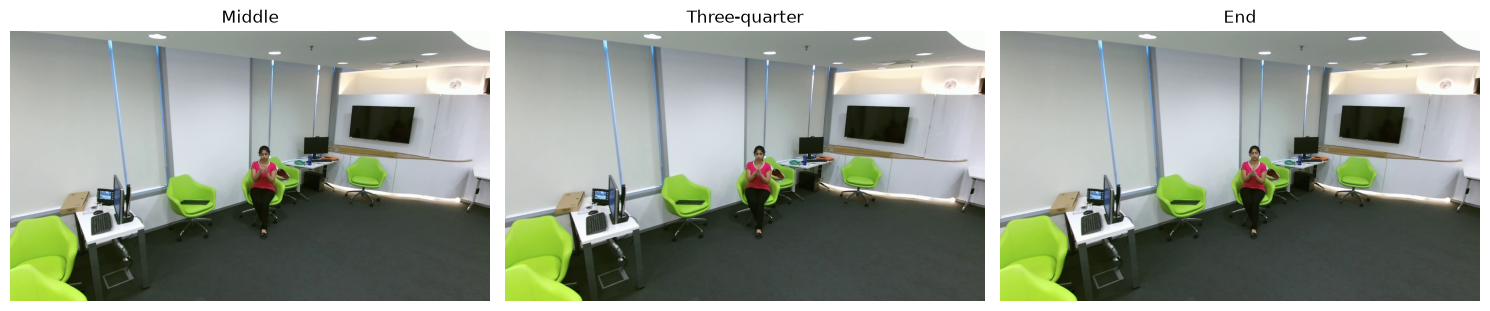

Middle Model Confidence: 40.86%
Middle Model Probabilities: tensor([[0.0032, 0.4086, 0.3804, 0.2078]])
Middle Model Prediction: Clapping = Class 2
---
Three-quarter Model Confidence: 47.67%
Three-quarter Model Probabilities: tensor([[0.0197, 0.2455, 0.4767, 0.2581]])
Three-quarter Model Prediction: Cross Arms = Class 3
---
End Model Confidence: 37.99%
End Model Probabilities: tensor([[0.0342, 0.3799, 0.2548, 0.3311]])
End Model Prediction: Clapping = Class 2
---
Overall Probabilities:  tensor([[0.0570, 1.0340, 1.1120, 0.7970]])
Overall Prediction:  Cross Arms = Class 3
True Label: class2


In [11]:
#random.seed(1)
def three_model_classifier(device, video_name="random", display_on = True):

    class_names = ["Capitulate  = Class 1", "Clapping = Class 2", "Cross Arms = Class 3", "Hand Waving = Class 4"]
    # use same transform configuration
    transform = transforms.Compose([
            transforms.Resize(256),
            transforms.CenterCrop(224),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
    
    overall_probs = torch.Tensor([0,0,0,0])

    if video_name == "random":
        # choose random frame from test file
        random_frame = random.choice(list(Path("data/three_quarter_frame/test").glob("class*/*.jpg")))
        # get video name
        video_name = random_frame.name.partition("rgb")[0] + "rgb"

    # find frames 
    middle_path = next(Path("data/middle_frame/").rglob(f"{video_name}_ending.jpg"), None)
    three_quarter_path = next(Path("data/three_quarter_frame/").rglob(f"{video_name}_ending.jpg"), None)
    end_path = next(Path("data/end_frame/").rglob(f"{video_name}_ending.jpg"), None)

    paths = [
                ("Middle", middle_path),
                ("Three-quarter", three_quarter_path),
                ("End", end_path)
            ]
    
    # find true label
    true_label = three_quarter_path.parent.name

    # display frames
    if display_on:
        _, axes = plt.subplots(1, 3,figsize=(15, 5))
        
        for ax, (title, path) in zip(axes, paths):
            image = Image.open(path).convert("RGB")
            ax.imshow(image)
            ax.set_title(title)
            ax.axis("off")
        plt.tight_layout()
        plt.show()

    # get predictions
    for (title,path), model_path in zip(paths, ["model_middle_", "model_three_quarter_", "model_end_"]):
        # transform image
        image = Image.open(path).convert("RGB")
        frame = transform(image).unsqueeze(0).to(device)

        # get model
        model = resnet_model.to(device)
        checkpoint = torch.load(f"checkpoints/{model_path}checkpoint.pth",map_location=device)
        model.load_state_dict(checkpoint[f"{model_path}state_dict"])
        model = model.to(device)
        model.eval()

        with torch.no_grad():
            output = model(frame)
            probabilities = torch.softmax(output, dim=1)
            confidence = probabilities[0, torch.argmax(probabilities, dim=1).item()].item()
            overall_probs = torch.add(overall_probs, probabilities)

        if display_on:
            print(f"{title} Model Confidence: {confidence:.2%}")
            print(f"{title} Model Probabilities: {probabilities}")
            print(f"{title} Model Prediction: {class_names[torch.argmax(probabilities, dim=1).item()]}")
            print("---")
    if display_on:
        print("Overall Probabilities: ", overall_probs)
        print("Overall Prediction: ", class_names[torch.argmax(overall_probs, dim=1).item()])
        print("True Label:", true_label)
    return torch.argmax(overall_probs, dim=1).item(), true_label

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
pred, _ = three_model_classifier(device, video_name="random", display_on=True)

### Evaluation of 3-Model-Classifier

In [12]:
def evaluate_3_model():

    # track labels and predictions
    true_labels = []
    preds = []

    # get all test video names
    test_dir = Path("data/end_frame/test")
    video_names = set(
        video.name.partition("rgb")[0] + "rgb"
        for class_dir in test_dir.iterdir()
        if class_dir.is_dir()
        for video in class_dir.iterdir()
        if video.is_file())

    for video_name in video_names:
        pred, true_label = three_model_classifier(device, video_name=video_name, display_on = False)

        true_labels.append(int(true_label.strip(string.ascii_letters))-1)
        preds.append(pred)

    overall_accuracy = accuracy_score(true_labels, preds)
    print(f"Overall Accuracy: {overall_accuracy:.4f}")
    print(classification_report(true_labels, preds))

    report = classification_report(
        true_labels,
        preds,
        output_dict=True
    )

    class_accuracy = {
        f"class{i+1}": report[str(i)]["recall"]
        for i in range(4)
    }

    return overall_accuracy, class_accuracy


acc_3_model, acc_classes_3_model = evaluate_3_model()

Overall Accuracy: 0.6928
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       144
           1       0.57      0.57      0.57       143
           2       0.60      0.71      0.65       143
           3       0.62      0.50      0.55       143

    accuracy                           0.69       573
   macro avg       0.69      0.69      0.69       573
weighted avg       0.69      0.69      0.69       573



## Experiment 1 & 2: Model Comparison

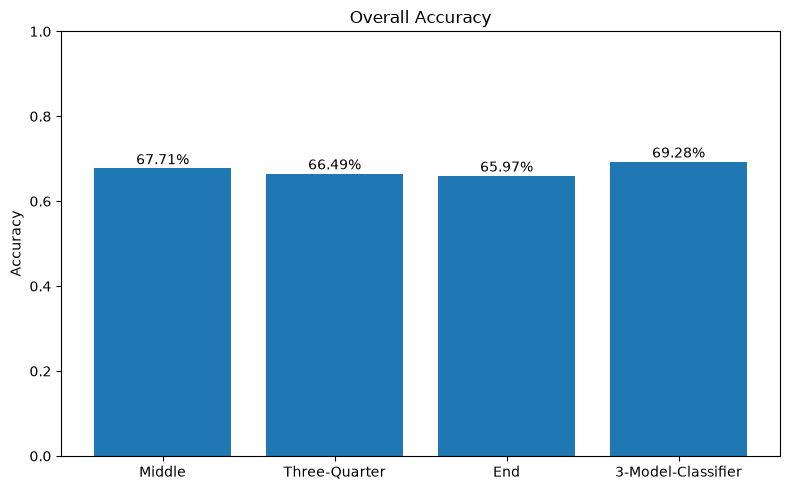

In [13]:
models = ["Middle","Three-Quarter","End", "3-Model-Classifier"]
total_acc = [
    acc_total_middle,
    acc_total_three_quarter,
    acc_total_end,
    acc_3_model
]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, total_acc)

plt.ylabel("Accuracy")
plt.title("Overall Accuracy")
plt.ylim(0, 1)

# Add values above bars
for bar, acc in zip(bars, total_acc):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{acc:.2%}",
        ha="center"
    )

plt.tight_layout()
plt.show()

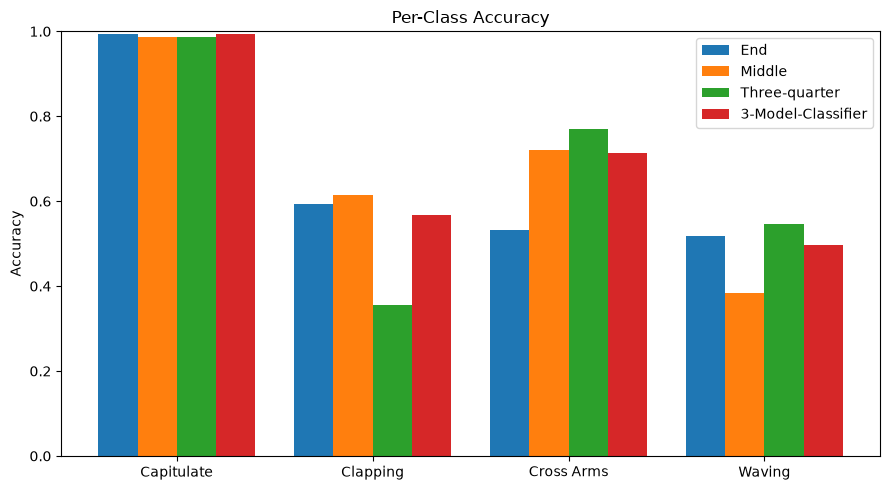

In [14]:
# plot per class accuracies
classes = list(acc_classes_end.keys())
x = np.arange(len(classes))
width = 0.2

plt.figure(figsize=(9, 5))

plt.bar(x - 1.5 * width,[acc_classes_end[c] for c in classes], width, label="End")
plt.bar(x - 0.5 * width,[acc_classes_middle[c] for c in classes], width, label="Middle")
plt.bar(x + 0.5 * width, [acc_classes_three_quarter[c] for c in classes], width, label="Three-quarter")
plt.bar(x + 1.5 * width, [acc_classes_3_model[c] for c in classes], width, label="3-Model-Classifier")

plt.xticks(x, ["Capitulate", "Clapping", "Cross Arms", "Waving"])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

## Hyperparameter Tuning

In [15]:
import optuna

def objective(trial):
    # Hyperparameters to search
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float(
        "weight_decay", 1e-6, 1e-2, log=True
    )
    optimizer_name = trial.suggest_categorical(
        "optimizer", ["SGD", "Adam"]
    )

    # Fresh pretrained model for every trial
    weights = ResNet18_Weights.DEFAULT
    model = resnet18(weights=weights)
    model.fc = torch.nn.Linear(model.fc.in_features, 4)
    model = model.to(device)

    # Only train FC
    if optimizer_name == "SGD":
        momentum = trial.suggest_float("momentum", 0.8, 0.99)

        optimizer = torch.optim.SGD(
            model.fc.parameters(),
            lr=lr,
            momentum=momentum,
            weight_decay=weight_decay
        )

    else:
        optimizer = torch.optim.Adam(
            model.fc.parameters(),
            lr=lr,
            weight_decay=weight_decay
        )

    criterion = torch.nn.CrossEntropyLoss()

    # Train
    epochs = 5
    for epoch in range(epochs):
        model.train()
        for images, labels in train_loader_three_quarter:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()
        print("Epoch: ", epoch)

    # Validation
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader_three_quarter:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    val_accuracy = correct / total

    return val_accuracy

study = optuna.create_study(direction="maximize")

study.optimize(
    objective,
    n_trials=10
)

print("Best validation accuracy:", study.best_value)
print("Best hyperparameters:")
print(study.best_params)

c:\Users\milen\miniconda3\envs\act_rec_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-08-20 14:57:36,668] A new study created in memory with name: no-name-b3fc01b6-71b3-4299-87fd-6aef7a59cf45


Epoch:  0
Epoch:  1
Epoch:  2
Epoch:  3
Epoch:  4


[I 2026-08-20 15:21:10,935] Trial 0 finished with value: 0.38070175438596493 and parameters: {'lr': 2.0123971941551805e-05, 'weight_decay': 3.64035175194383e-05, 'optimizer': 'Adam'}. Best is trial 0 with value: 0.38070175438596493.


Epoch:  0
Epoch:  1
Epoch:  2
Epoch:  3
Epoch:  4


[I 2026-08-20 15:45:19,483] Trial 1 finished with value: 0.4456140350877193 and parameters: {'lr': 3.4486297631692785e-05, 'weight_decay': 2.9481444158221802e-06, 'optimizer': 'Adam'}. Best is trial 1 with value: 0.4456140350877193.


...

Epoch:  0
Epoch:  1
Epoch:  2
Epoch:  3
Epoch:  4


[I 2026-08-20 18:28:16,768] Trial 8 finished with value: 0.3280701754385965 and parameters: {'lr': 1.020050638711119e-05, 'weight_decay': 0.0006633479642944003, 'optimizer': 'SGD', 'momentum': 0.837494783595926}. Best is trial 6 with value: 0.6771929824561403.


Epoch:  0
Epoch:  1
Epoch:  2
Epoch:  3
Epoch:  4


[I 2026-08-20 18:49:48,996] Trial 9 finished with value: 0.6824561403508772 and parameters: {'lr': 0.0035562602273362834, 'weight_decay': 0.006032473823690534, 'optimizer': 'SGD', 'momentum': 0.8542568465008153}. Best is trial 9 with value: 0.6824561403508772.


Best validation accuracy: 0.6824561403508772
Best hyperparameters:
{'lr': 0.0035562602273362834, 'weight_decay': 0.006032473823690534, 'optimizer': 'SGD', 'momentum': 0.8542568465008153}
